In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import seaborn as sns
import math as mt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
#from skimage.io import imread, imsave

np.random.seed(42)

In [3]:
L = 1.5*(10**-3) #Гн
C = 4.7*(10**-2)*(10**-6) #Ф
nu0 = 1/(np.pi*np.sqrt(L*C))
R0 = np.sqrt(L/C)
float(nu0), float(R0)

# BX_AX = np.array([4.5,
#                                  8.5,
#                                  11.5,
#                                  11.5,
#                                  9,
#                                  12.5,
#                                  13,
#                                  13,
#                                  8.5,
#                                  3
#                                  ])

# dts = np.array([20.0,
#                           17.6,
#                           18.80,
#                           16.80,
#                           17.60,
#                           18.20,
#                           19.00,
#                           20,
#                           20.7,
#                           24
#                           ])

# dts = dts / 2

from typing import Callable
import numpy as np


def Lorentzian(f: float,
               f_0: float,
               A_max: float,
               gamma: float) -> float:
    """
    Функция Лоренца.

    Args:
        f (float): частота, на которой вычисляется значение.
        f_0 (float): резонансная частота.
        A_max (float): максимальная амплитуда.
        gamma (float): ширина резонанса.

    Returns:
        float: значение функции Лоренца на частоте f.
    """

    return A_max / (1 + (2 * (f - f_0) / gamma)**2)

def ApproximateResonanceCurve(f_0: float,
                              f_1: float,
                              f_2: float,
                              A_max: float = 1
                              ) -> tuple[Callable, float]:
    """
    Аппроксимирует резонансную кривую по трём точкам.

    Args:
        f0 (float): резонансная частота.
        f1 (float): частота слева от резонанса, где амплитуда A_max / sqrt(2).
        f2 (float): частота справа от резонанса, где амплитуда A_max / sqrt(2).
        A_max (float, optional): максимальная амплитуда. Defaults to 1.

    Returns:
        tuple[Callable, float]: функция, представляющую аппроксимированную резонансную кривую, 
                                ширина резонанса
    """

    gamma_factor = np.sqrt(np.sqrt(2) - 1)
    gamma_1 = 2 * abs(f_1 - f_0) / gamma_factor
    gamma_2 = 2 * abs(f_2 - f_0) / gamma_factor
    gamma = (gamma_1 + gamma_2) / 2

    def ResonanceCurve(f):
        return Lorentzian(f, f_0, A_max, gamma)

    return ResonanceCurve, gamma

ampl_inf_volt = np.array([515, 495, 420, 300, 165, 24, 165, 305, 420, 510])
ampl_zero_volt_first = np.array([560, 540, 525, 500, 450, 385, 330, 255, 180, 0])
ampl_zero_volt_second = np.array([505, 440, 280, 80, 155, 360, 470, 490, 415, 0])
ampl_zero_volt_third = np.array([435, 310, 280, 315, 435, 320, 300, 310, 410, 0])
res_inf=np.array([5.7, 11.3, 16.6, 21.4, 26.2, 29.6, 32.9, 35.3, 36.7]) * 10**3 #132.9
res_zero=np.array([8.5, 14.00, 19.2, 23.9, 28.0, 31.5, 34.3, 36.2]) * 10**3

Теоретическая предельная частота (nu0): 37.91 кГц

--- Результаты расчетов эксперимента ---
Частота (кГц)   | dt (мкс)   | Фаза (град)
4.0             | 10.00      | 14.4      
8.0             | 8.80       | 25.3      
12.0            | 9.40       | 40.6      
16.0            | 8.40       | 48.4      
20.0            | 8.80       | 63.4      
24.0            | 9.10       | 78.6      
28.0            | 9.50       | 95.8      
32.0            | 10.00      | 115.2     
36.0            | 10.75      | 139.3     
38.0            | 12.60      | 172.4     


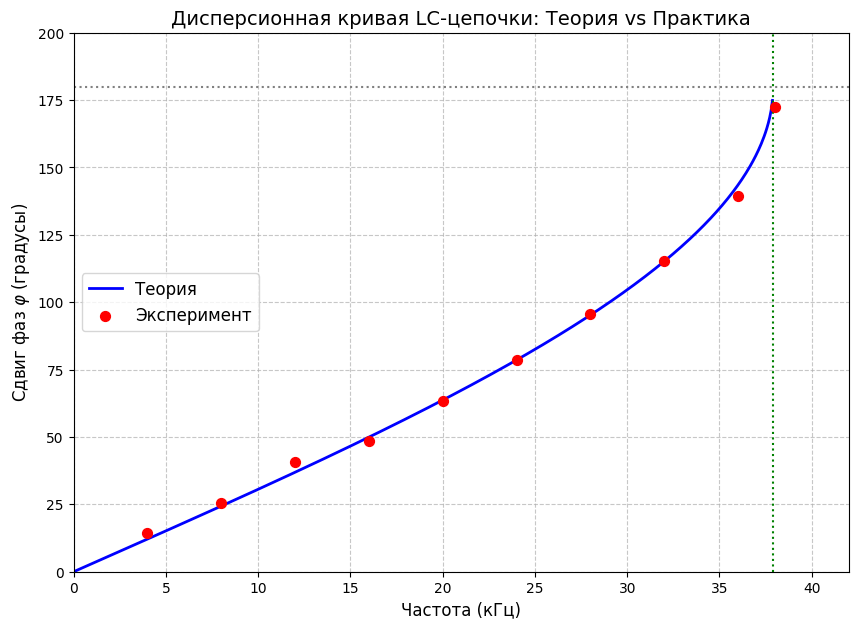

In [4]:

# Расчет теоретической предельной частоты
# w0 = 2 / sqrt(LC) -> nu0 = 1 / (pi * sqrt(LC))
nu0 = 1 / (np.pi * np.sqrt(L * C))
print(f"Теоретическая предельная частота (nu0): {nu0/1000:.2f} кГц")

# ==========================================
# 2. ЭКСПЕРИМЕНТАЛЬНЫЕ ДАННЫЕ
# ==========================================
# частоты (Гц)
frequencies = np.array([4, 8, 12, 16, 20, 24, 28, 32, 36, 38]) * 10**3

# измерения "расстояния" (условные единицы из вопроса)
dts_raw = np.array([20.0, 17.6, 18.80, 16.80, 17.60, 18.20, 19.00, 20, 21.5, 25.2])

# Обработка времени:
# 1. Делим на 2
# 2. Переводим микросекунды (1e-6) в секунды
dts_seconds = (dts_raw / 2) * 1e-6

# Перевод в фазу (градусы): phi = dt * f * 360
phi_exp = dts_seconds * frequencies * 360

# Вывод рассчитанных точек в консоль для проверки
print("\n--- Результаты расчетов эксперимента ---")
print(f"{'Частота (кГц)':<15} | {'dt (мкс)':<10} | {'Фаза (град)':<10}")
for f, t, p in zip(frequencies, dts_seconds*1e6, phi_exp):
    print(f"{f/1000:<15.1f} | {t:<10.2f} | {p:<10.1f}")

# ==========================================
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ==========================================
plt.figure(figsize=(10, 7))

# --- Теоретическая кривая ---
# Строим от 0 до чуть меньше предела, чтобы не было ошибки деления на ноль
nu_theory = np.linspace(0, nu0 * 0.999, 500)
# Формула: phi = 2 * arcsin(nu / nu0)
phi_theory_rad = 2 * np.arcsin(nu_theory / nu0)
phi_theory_deg = np.degrees(phi_theory_rad)

plt.plot(nu_theory / 1000, phi_theory_deg, label='Теория', color='blue', linewidth=2)

# --- Экспериментальные точки ---
plt.scatter(frequencies / 1000, phi_exp, color='red', s=50, zorder=5, label='Эксперимент')

# Оформление
plt.title('Дисперсионная кривая LC-цепочки: Теория vs Практика', fontsize=14)
plt.xlabel('Частота (кГц)', fontsize=12)
plt.ylabel('Сдвиг фаз $\\varphi$ (градусы)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Линии ограничений
plt.axhline(y=180, color='gray', linestyle=':', label='180° (Pi)')
plt.axvline(x=nu0/1000, color='green', linestyle=':', label=f'nu0 = {nu0/1000:.1f} кГц')

plt.ylim(0, 200)
plt.xlim(0, 42)

plt.show()


<>:44: SyntaxWarning: invalid escape sequence '\i'
<>:44: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Аким Тарасов\AppData\Local\Temp\ipykernel_21676\192447118.py:44: SyntaxWarning: invalid escape sequence '\i'
  label='Эксперимент ($Z_K=\infty$)')


Предельная частота (nu0): 37.91 кГц


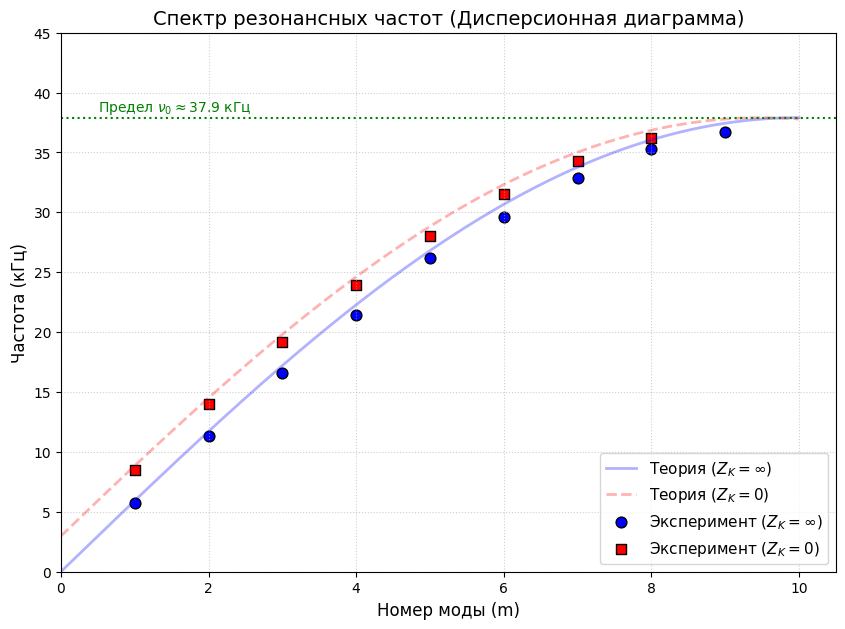

In [51]:
N = 10          # Число ячеек

# Теоретическая предельная частота
nu0 = 1 / (np.pi * np.sqrt(L * C))
print(f"Предельная частота (nu0): {nu0/1000:.2f} кГц")

# ==========================================
# 2. ЭКСПЕРИМЕНТАЛЬНЫЕ ДАННЫЕ
# ==========================================
# Резонансы (переводим в Гц)
# resonances = {
#     "inf": np.array([5.7, 11.3, 16.6, 21.4, 26.2, 29.6, 32.9, 35.3, 36.7]) * 10**3,
#     "zero": np.array([8.5, 14.00, 19.2, 23.9, 28.0, 31.5, 34.3, 36.2]) * 10**3
# }

# Номера мод (m)
m_inf = np.arange(1, len(res_inf) + 1)
m_zero = np.arange(1, len(res_zero) + 1)

# ==========================================
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ==========================================
plt.figure(figsize=(10, 7))

# --- А. ТЕОРЕТИЧЕСКИЕ КРИВЫЕ (Сплошные линии) ---
# Создаем непрерывный диапазон m для плавности линий
m_theory = np.linspace(0, 10, 200)

# Формула для разомкнутой (Zk = inf): nu = nu0 * sin(pi * m / 2N)
nu_theory_inf = nu0 * np.sin((np.pi * m_theory) / (2 * N))

# Формула для замкнутой (Zk = 0): nu = nu0 * sin(pi * (m + 0.5) / 2N)
# Сдвиг на 0.5 объясняет, почему точки "zero" лежат между точками "inf"
nu_theory_zero = nu0 * np.sin((np.pi * (m_theory + 0.5)) / (2 * N))

plt.plot(m_theory, nu_theory_inf / 1000, color='blue', alpha=0.3, linewidth=2, 
         label=r'Теория ($Z_K=\infty$)')
plt.plot(m_theory, nu_theory_zero / 1000, color='red', alpha=0.3, linewidth=2, linestyle='--',
         label=r'Теория ($Z_K=0$)')


# --- Б. ЭКСПЕРИМЕНТАЛЬНЫЕ ТОЧКИ (Без линий) ---
plt.scatter(m_inf, res_inf / 1000, color='blue', s=60, marker='o', edgecolors='black', 
            label='Эксперимент ($Z_K=\infty$)')

plt.scatter(m_zero, res_zero / 1000, color='red', s=60, marker='s', edgecolors='black', 
            label='Эксперимент ($Z_K=0$)')


# ==========================================
# 4. ОФОРМЛЕНИЕ
# ==========================================
plt.title('Спектр резонансных частот (Дисперсионная диаграмма)', fontsize=14)
plt.xlabel('Номер моды (m)', fontsize=12)
plt.ylabel('Частота (кГц)', fontsize=12)

# Сетка и легенда
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

# Добавляем линию предельной частоты
plt.axhline(y=nu0/1000, color='green', linestyle=':', label='Предел')
plt.text(0.5, (nu0/1000)+0.5, f'Предел $\\nu_0 \\approx {nu0/1000:.1f}$ кГц', color='green')

plt.ylim(0, 45)
plt.xlim(0, 10.5)

plt.show()


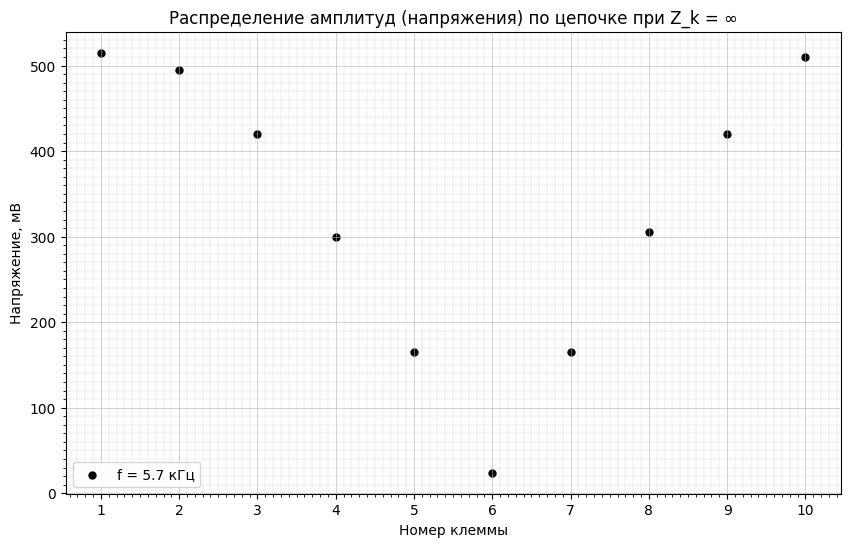

In [52]:
_, axs = plt.subplots(1, 1, figsize=(10, 6))

axs.set_title("Распределение амплитуд (напряжения) по цепочке при Z_k = ∞")
axs.set_xlabel("Номер клеммы")
axs.set_ylabel("Напряжение, мВ")

axs.scatter(range(1, 10 + 1),
            ampl_inf_volt,
            marker="o",
            s=25,
            label="f = 5.7 кГц",
            color="black")

axs.xaxis.set_major_locator(MultipleLocator(1))
axs.xaxis.set_minor_locator(AutoMinorLocator(10))
axs.yaxis.set_minor_locator(AutoMinorLocator(10))

plt.grid(which='minor', linestyle='--', linewidth=0.2)
plt.grid(which='major', linewidth=0.4)

plt.legend()
plt.show()

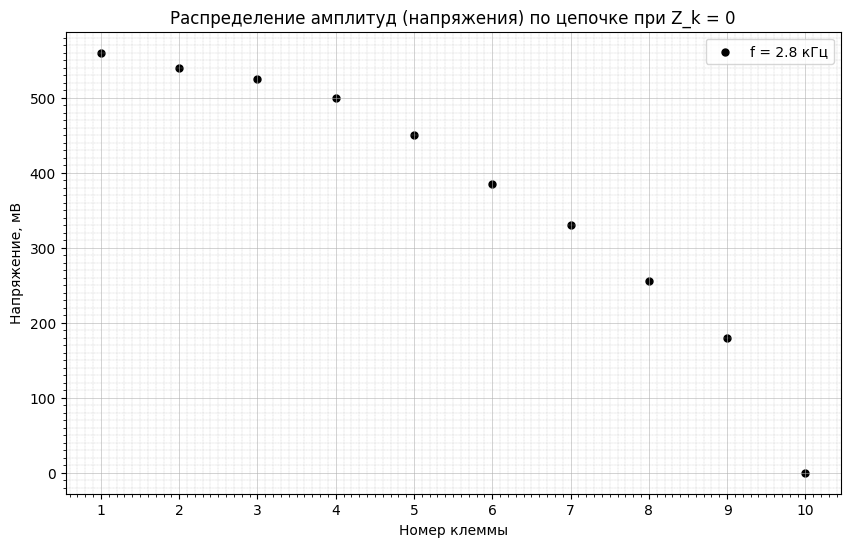

In [5]:
_, axs = plt.subplots(1, 1, figsize=(10, 6))

axs.set_title("Распределение амплитуд (напряжения) по цепочке при Z_k = 0")
axs.set_xlabel("Номер клеммы")
axs.set_ylabel("Напряжение, мВ")

axs.scatter(range(1, 10 + 1),
            ampl_zero_volt_first,
            marker="o",
            s=25,
            label="f = 2.8 кГц",
            color="black")

axs.xaxis.set_major_locator(MultipleLocator(1))
axs.xaxis.set_minor_locator(AutoMinorLocator(10))
axs.yaxis.set_minor_locator(AutoMinorLocator(10))

plt.grid(which='minor', linestyle='--', linewidth=0.2)
plt.grid(which='major', linewidth=0.4)

plt.legend()
plt.show()

Оценка ширины резонанса: 1413.9343163673338
Оценка добротности: 6.263736263736264


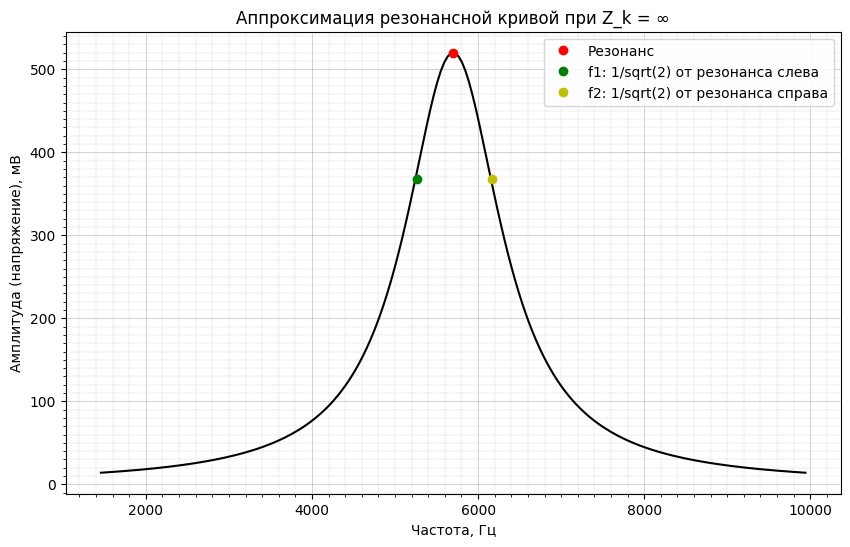

In [55]:
_, axs = plt.subplots(1, 1, figsize=(10, 6))

axs.set_title("Аппроксимация резонансной кривой при Z_k = ∞")
axs.set_xlabel("Частота, Гц")
axs.set_ylabel("Амплитуда (напряжение), мВ")

f_0 = 5.7 * 10**3  # резонансная частота
f_1 = 5.26 * 10**3  # частота слева, где амплитуда 1/sqrt(2)
f_2 = 6.17 * 10**3  # частота справа, где амплитуда 1/sqrt(2)
resonance = 520

ResonanceCurve, gamma = ApproximateResonanceCurve(f_0, f_1, f_2, resonance)

print(f"Оценка ширины резонанса: {gamma}")
print(f"Оценка добротности: {f_0 / (f_2 - f_1)}")

frequencies = np.linspace(f_0 - 3 * gamma, f_0 + 3 * gamma, 200)
amplitudes = [ResonanceCurve(f) for f in frequencies]
plt.plot(frequencies, amplitudes, color="black")

plt.plot(f_0, resonance, 'ro', label='Резонанс')
plt.plot(f_1, resonance / np.sqrt(2), 'go', label='f1: 1/sqrt(2) от резонанса слева')
plt.plot(f_2, resonance / np.sqrt(2), 'yo', label='f2: 1/sqrt(2) от резонанса справа')

axs.xaxis.set_minor_locator(AutoMinorLocator(10))
axs.yaxis.set_minor_locator(AutoMinorLocator(10))

plt.grid(which='minor', linestyle='--', linewidth=0.2)
plt.grid(which='major', linewidth=0.4)

plt.legend()
plt.show()

Оценка ширины резонанса: 1600.3871932509383
Оценка добротности: 2.7184466019417477


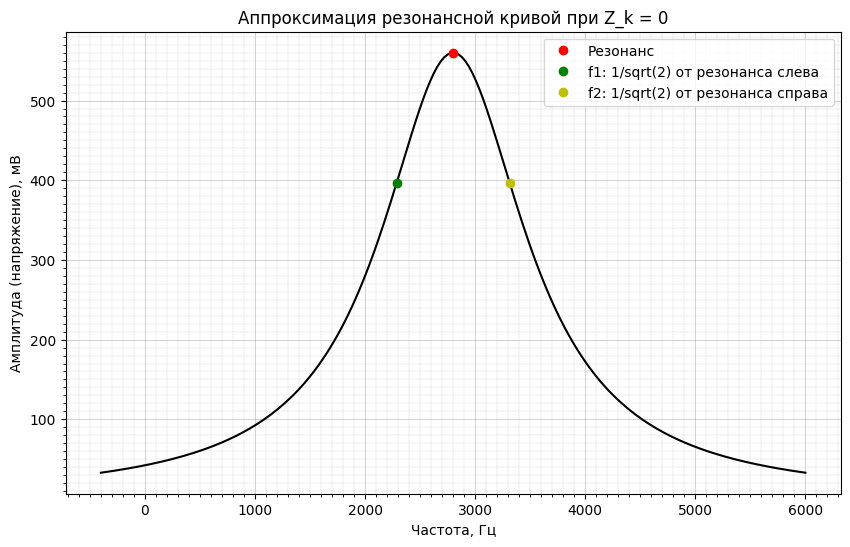

In [56]:
_, axs = plt.subplots(1, 1, figsize=(10, 6))

axs.set_title("Аппроксимация резонансной кривой при Z_k = 0")
axs.set_xlabel("Частота, Гц")
axs.set_ylabel("Амплитуда (напряжение), мВ")

f_0 = 2.8 * 10**3   # резонансная частота
f_1 = 2.29 * 10**3  # частота слева, где амплитуда 1/sqrt(2)
f_2 = 3.32 * 10**3  # частота справа, где амплитуда 1/sqrt(2)
resonance = 560

ResonanceCurve, gamma = ApproximateResonanceCurve(f_0, f_1, f_2, resonance)

print(f"Оценка ширины резонанса: {gamma}")
print(f"Оценка добротности: {f_0 / (f_2 - f_1)}")

frequencies = np.linspace(f_0 - 2 * gamma, f_0 + 2 * gamma, 200)
amplitudes = [ResonanceCurve(f) for f in frequencies]
axs.plot(frequencies, amplitudes, color="black")

axs.plot(f_0, resonance, 'ro', label='Резонанс')
axs.plot(f_1, resonance / np.sqrt(2), 'go', label='f1: 1/sqrt(2) от резонанса слева')
axs.plot(f_2, resonance / np.sqrt(2), 'yo', label='f2: 1/sqrt(2) от резонанса справа')

axs.xaxis.set_minor_locator(AutoMinorLocator(10))
axs.yaxis.set_minor_locator(AutoMinorLocator(10))

plt.grid(which='minor', linestyle='--', linewidth=0.2)
plt.grid(which='major', linewidth=0.4)

plt.legend()
plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Аким Тарасов\AppData\Local\Temp\ipykernel_21676\2190288744.py:49: SyntaxWarning: invalid escape sequence '\s'
  label=f'Аппроксимация: $V \sim e^{{-{psi_calculated:.2f} n}}$')
C:\Users\Аким Тарасов\AppData\Local\Temp\ipykernel_21676\2190288744.py:62: RuntimeWarning: divide by zero encountered in log
  ax_inset.plot(links, np.log(voltage_data), 'o-', color='green', markersize=5)


Рассчитанный коэффициент затухания (psi): 0.682


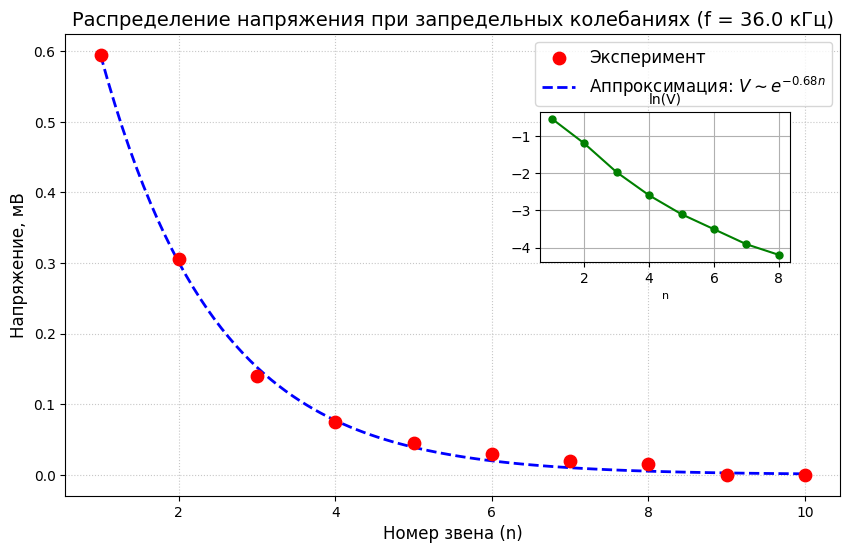

In [62]:
from scipy.optimize import curve_fit

# ==========================================
# 1. ВАШИ ДАННЫЕ (ЗАМЕНИТЕ НА СВОИ)
# ==========================================
# Номера звеньев (от 1 до 10)
links = np.arange(1, 11)

# Измеренные напряжения (мВ или условные единицы)
# Вставьте сюда значения, которые вы сняли при частоте > 38 кГц
# Они должны быстро убывать (примерные данные ниже):
voltage_data = extreme_frequency_voltage = np.array([595, 305, 140, 75, 45, 30, 20, 15, 0,0]) * 10**(-3)

# Частота, на которой проводилось измерение (для заголовка)
freq_measurement = 36.0  # кГц

# ==========================================
# 2. РАСЧЕТ КОЭФФИЦИЕНТА ЗАТУХАНИЯ (PSI)
# ==========================================
# Теоретическая зависимость: V = V0 * exp(-psi * n)
def exp_decay(n, v0, psi):
    return v0 * np.exp(-psi * n)

# Подгонка (аппроксимация) экспериментальных данных под экспоненту
# popt содержит найденные [v0, psi]
try:
    popt, pcov = curve_fit(exp_decay, links, voltage_data, p0=[voltage_data[0], 0.5])
    psi_calculated = popt[1]
    v0_calculated = popt[0]
except:
    psi_calculated = 0
    v0_calculated = 0
    print("Не удалось подобрать экспоненту. Проверьте данные.")

print(f"Рассчитанный коэффициент затухания (psi): {psi_calculated:.3f}")

# ==========================================
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Экспериментальные точки
ax.scatter(links, voltage_data, color='red', s=80, label='Эксперимент', zorder=5)

# Теоретическая кривая (аппроксимация)
x_smooth = np.linspace(1, 10, 100)
ax.plot(x_smooth, exp_decay(x_smooth, v0_calculated, psi_calculated), 
        color='blue', linestyle='--', linewidth=2, 
        label=f'Аппроксимация: $V \sim e^{{-{psi_calculated:.2f} n}}$')

# Оформление (как вы просили, но ось X исправлена на номер звена)
ax.set_title(f"Распределение напряжения при запредельных колебаниях (f = {freq_measurement} кГц)", fontsize=14)
ax.set_xlabel("Номер звена (n)", fontsize=12) 
ax.set_ylabel("Напряжение, мВ", fontsize=12)

ax.grid(True, which='both', linestyle=':', alpha=0.7)
ax.legend(fontsize=12)

# Дополнительно: график в логарифмическом масштабе (врезка)
# Если график прямая в логарифмах - это доказательство экспоненциального затухания
ax_inset = fig.add_axes([0.6, 0.5, 0.25, 0.25]) # [left, bottom, width, height]
ax_inset.plot(links, np.log(voltage_data), 'o-', color='green', markersize=5)
ax_inset.set_title("ln(V)", fontsize=10)
ax_inset.set_xlabel("n", fontsize=8)
ax_inset.grid(True)

plt.show()


<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Аким Тарасов\AppData\Local\Temp\ipykernel_21676\531443725.py:57: SyntaxWarning: invalid escape sequence '\p'
  axs.text(5, U_data.max()*0.7, f"$\psi = {psi_fit:.3f}$ (1/яч)",


Рассчитанный декремент затухания (psi): 0.682


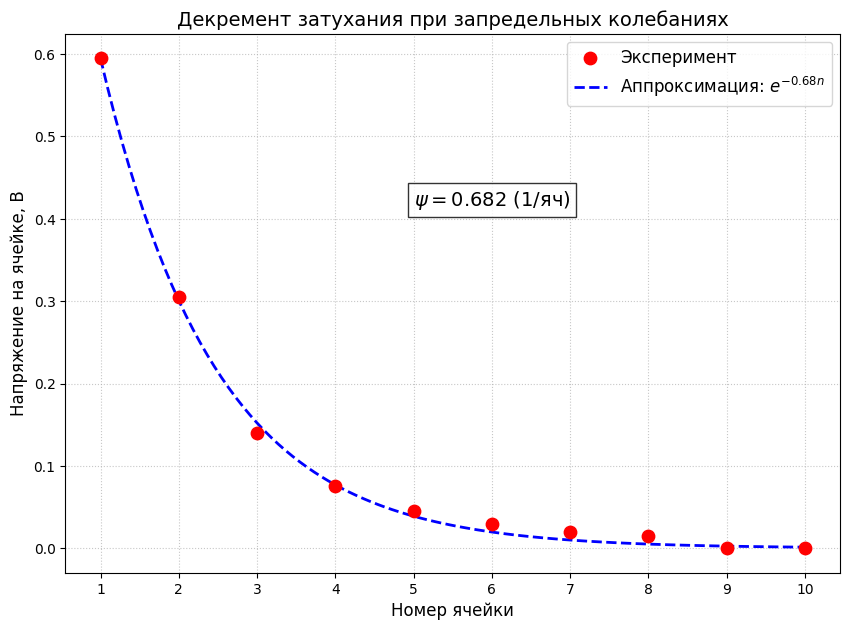

In [ ]:

from scipy.optimize import curve_fit

# ==========================================
# 1. ВАШИ ДАННЫЕ (ВСТАВЬТЕ СЮДА СВОИ ЧИСЛА)
# ==========================================
# Номера ячеек от 1 до 10
n_cells = np.arange(1, 11)

# Напряжение на каждой ячейке (в Вольтах или мВ)
U_data = voltage_data = extreme_frequency_voltage = np.array([595, 305, 140, 75, 45, 30, 20, 15, 0,0]) * 10**(-3)

# ==========================================
# 2. РАСЧЕТ ДЕКРЕМЕНТА (PSI)
# ==========================================
# Определяем функцию экспоненциального затухания: U = A * exp(-psi * n)
def exponential_decay(n, A, psi):
    return A * np.exp(-psi * n)

# Подгоняем кривую под ваши точки
# p_opt вернет [A, psi]
try:
    p_opt, p_cov = curve_fit(exponential_decay, n_cells, U_data, p0=[U_data[0], 0.5])
    A_fit, psi_fit = p_opt
except:
    A_fit, psi_fit = 0, 0
    print("Ошибка аппроксимации. Проверьте данные.")

print(f"Рассчитанный декремент затухания (psi): {psi_fit:.3f}")

# ==========================================
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ==========================================
fig, axs = plt.subplots(figsize=(10, 7))

# Экспериментальные точки
axs.scatter(n_cells, U_data, color='red', s=80, label='Эксперимент', zorder=5)

# Теоретическая кривая (аппроксимация)
x_smooth = np.linspace(1, 10, 100)
axs.plot(x_smooth, exponential_decay(x_smooth, A_fit, psi_fit), 
         color='blue', linestyle='--', linewidth=2, 
         label=f'Аппроксимация: $e^{{-{psi_fit:.2f} n}}$')


# --- ОФОРМЛЕНИЕ ПО ВАШЕМУ ЗАПРОСУ ---
axs.set_title("Декремент затухания при запредельных колебаниях", fontsize=14)
axs.set_xlabel("Номер ячейки", fontsize=12)
axs.set_ylabel("Напряжение на ячейке, В", fontsize=12)

# Дополнительное оформление
axs.grid(True, which='both', linestyle=':', alpha=0.7)
axs.legend(fontsize=12)
axs.set_xticks(n_cells) # Чтобы на оси X были целые числа от 1 до 10

# Вывод значения psi прямо на график
axs.text(5, U_data.max()*0.7, f"$\psi = {psi_fit:.3f}$ (1/яч)", 
         fontsize=14, bbox=dict(facecolor='white', alpha=0.8))

plt.show()


In [ ]:

# v = 1 / sqrt(LC)
v_theory = 1 / np.sqrt(L * C)

print(f"--- ТЕОРИЯ ---")
print(f"L = {L} Гн, C = {C} Ф")
print(f"Теоретическая скорость волны: {v_theory:.0f} ячеек/с")


# --- 2. ЭКСПЕРИМЕНТАЛЬНЫЙ РАСЧЕТ ---
# (первые 3 точки - самые надежные для оценки скорости)
# dts_raw - ваши сырые данные, dts_sec - переведенные в секунды

dts_raw_low_freq = np.array([20.0, 17.6, 18.8]) # Для 4, 8, 12 кГц
dts_sec = (dts_raw_low_freq / 2) * 1e-6   # Перевод в секунды

# Скорость v = 1 / dt
v_exp_values = 1 / dts_sec
v_exp_avg = np.mean(v_exp_values)

print(f"\n--- ЭКСПЕРИМЕНТ (по низким частотам) ---")
for i, dt in enumerate(dts_sec):
    print(f"Точка {i+1} (dt={dt*1e6:.1f} мкс): v = {1/dt:.0f} ячеек/с")

print(f"\nСредая экспериментальная скорость: {v_exp_avg:.0f} ячеек/с")

# Ошибка
error = abs(v_exp_avg - v_theory) / v_theory * 100
print(f"\nОтклонение от теории: {error:.1f}%")


--- ТЕОРИЯ ---
L = 0.0015 Гн, C = 4.7e-08 Ф
Теоретическая скорость волны: 119098 ячеек/с

--- ЭКСПЕРИМЕНТ (по низким частотам) ---
Точка 1 (dt=10.0 мкс): v = 100000 ячеек/с
Точка 2 (dt=8.8 мкс): v = 113636 ячеек/с
Точка 3 (dt=9.4 мкс): v = 106383 ячеек/с

Средая экспериментальная скорость: 106673 ячеек/с

Отклонение от теории: 10.4%


1) Дисперсионная кривая (phi(omega))
2) Резонансы для двух случаев, сравнение
3) Запредельные колебания
4) Q, скорость

Как рассчитывать скорость волны в LC-цепочке (теоретически и экспериментально)
1. Теоретическая скорость волны
В LC-цепочке волны распространяются с частотой (\omega) и сдвигом фазы между соседними ячейками (\varphi). Закон дисперсии, связывающий угловую частоту (\omega) и фазовый сдвиг (\varphi), задаётся формулой:

[ \omega = \omega_0 \sin \frac{\varphi}{2} ]

где (\omega_0 = \frac{1}{\sqrt{LC}}) — предельная частота цепочки.

Фазовая скорость волны (v_{\text{ф}}) в ячейках за один колебательный период рассчитывается как:

[ v_{\text{ф}} = \frac{\omega}{\varphi} \quad (\text{в ячейках в секунду}) ]

Здесь (\omega) — угловая частота колебаний (рад/с)
(\varphi) — фазовый сдвиг по цепочке (радианы на одну ячейку)
Поскольку в эксперименте удобно работать с частотой в герцах (\nu = \frac{\omega}{2\pi}), и фазовый сдвиг можно измерять между соседними ячейками (\varphi), формулу можно записать так:

[ v_{\text{ф}} = \frac{2\pi \nu}{\varphi} ]

Единицы: если (\nu) в Гц, (\varphi) в радианах, то (v_{\text{ф}}) в ячейках/сек.

2. Экспериментальная скорость волны
Экспериментально фазовый сдвиг (\varphi) между соседними ячейками можно измерить с осциллографа:

Подайте напряжения с двух соседних узлов цепочки на X и Y входы осциллографа.
Получите фигуру Лиссажу (эллипс).
Измерьте сдвиг фаз (\varphi) по формуле:
[ \sin \varphi = \frac{y_0}{A} ]

где (y_0) — половина высоты эллипса по Y, а (A) — амплитуда.

Или измеряете сдвиг по времени (\Delta t) между сигналами соседних ячеек, тогда:

[ \varphi = 2 \pi \nu \Delta t ]

После вычисления (\varphi) можно применять формулу для экспериментальной скорости:

[ v_{\text{эксп}} = \frac{2 \pi \nu}{\varphi} ]

3. Пример вычисления
Пусть при частоте (\nu = 10,\text{кГц}) измерили фазовый сдвиг (\varphi = 0.3, \text{рад}).

Тогда теоретическую или экспериментальную скорость волны в ячейках/считаем так:

[ v = \frac{2 \pi \times 10,000}{0.3} \approx \frac{62,832}{0.3} \approx 209,441 , \text{яч./с} ]

Итог
Измерьте сдвиг фаз (\varphi) между соседними ячейками.
Подставьте (\nu) и (\varphi) в формулу (v = \frac{2\pi \nu}{\varphi}).
Сравните с теоретической скоростью, рассчитываемой через (\omega_0 = 1/\sqrt{LC}).
Если нужно, могу помочь написать Python-скрипт для расчёта и визуализации (v(\nu)) на основе экспериментальных фазовых сдвигов.

Готов помочь!